# Analise de Acidentes nas Rodovias Federais

**Autores:** Chrysthyan Matheus e Eric Gabriel

Notebook oficial da disciplina de Programacao para Analise de Dados. O objetivo e organizar a leitura, validacao, conversao e comparacao de desempenho sobre os dados de acidentes.

O processamento paralelo distribuido com Dask em multiplas maquinas fisicas não foi implementado nesta versao por limitacao externa. A comparacao de desempenho com Dask local foi feita.


In [7]:
import os
import sys
import glob
import textwrap
from datetime import datetime
from pathlib import Path

import pandas as pd
import polars as pl
import pyarrow.compute as pc
import pyarrow.dataset as ds
import dask.dataframe as dd
from dask.distributed import Client, LocalCluster
import matplotlib.pyplot as plt
import seaborn as sns

# Caminhos do projeto.
# A deteccao abaixo permite executar o notebook pela raiz do projeto ou pela pasta notebooks/.
BASE_DIR = Path.cwd()
if BASE_DIR.name == "notebooks":
    BASE_DIR = BASE_DIR.parent

RAW_DATA_DIR = BASE_DIR / "data" / "raw"
PROCESSED_DATA_DIR = BASE_DIR / "data" / "processed"
REPORTS_DIR = BASE_DIR / "reports"
PARQUET_DIR = PROCESSED_DATA_DIR / "dados_otimizados"

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# Permite importar os modulos locais em src/ mesmo quando o notebook e aberto pela pasta notebooks/.
if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

from src.etl.schema import (
    DATE_COLUMNS,
    SCHEMA_PANDAS,
    TIME_COLUMNS,
    columns_to_read,
    validate_dataframe_quality,
    validate_required_columns,
)
from src.etl.time_filters import add_period_columns, filter_by_quarter, filter_by_semester, summarize_by_period
from src.utils.benchmark import conversion_size_report, measure_seconds
from src.utils.plotting import apply_dark_theme, save_report_figure


## 1 - Definicao e validacao dos schemas

Nesta etapa os CSVs brutos sao lidos com tipos definidos explicitamente. A leitura tipada funciona como uma primeira validacao pratica: se uma coluna esperada estiver ausente ou possuir valores incompatíveis com o tipo definido, a etapa de carga/conversao falha e o erro e registrado na saida da celula.

Para deixar a validacao mais formal, o notebook tambem gera relatorios de colunas ausentes, tipos encontrados, valores nulos e valores invalidos. Esses relatorios ajudam a comprovar que o schema foi aplicado e que os dados principais estao consistentes antes da analise.

Os arquivos convertidos sao salvos em Parquet na pasta `data/processed/dados_otimizados/`, preservando os CSVs originais em `data/raw/`.


In [8]:
# Pasta de saida dos arquivos Parquet gerados a partir dos CSVs brutos.
pasta_saida = PARQUET_DIR
os.makedirs(pasta_saida, exist_ok=True)


In [9]:
# Mapeamento dos CSVs brutos usando a estrutura padronizada do projeto.
caminho_busca = str(RAW_DATA_DIR / "*.csv")
arquivos_csv = sorted(glob.glob(caminho_busca))

print(f"Encontrei {len(arquivos_csv)} arquivos CSV em {RAW_DATA_DIR}!")


Encontrei 9 arquivos CSV em /home/chrys/Downloads/Trabalho Chamy/pad_acidentes_prf/data/raw!


In [10]:
# Amostra inicial para visualizar as colunas e os tipos originais antes da aplicacao do schema.
primeiro_arquivo = arquivos_csv[0]
df_amostra = pd.read_csv(primeiro_arquivo, sep=";", nrows=1000, encoding="latin1")
df_amostra.info(memory_usage="deep")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 37 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      1000 non-null   int64  
 1   pesid                   959 non-null    float64
 2   data_inversa            1000 non-null   object 
 3   dia_semana              1000 non-null   object 
 4   horario                 1000 non-null   object 
 5   uf                      1000 non-null   object 
 6   br                      996 non-null    float64
 7   km                      996 non-null    object 
 8   municipio               1000 non-null   object 
 9   causa_principal         1000 non-null   object 
 10  causa_acidente          1000 non-null   object 
 11  ordem_tipo_acidente     1000 non-null   int64  
 12  tipo_acidente           1000 non-null   object 
 13  classificacao_acidente  988 non-null    object 
 14  fase_dia                1000 non-null   o

In [11]:
# Schema centralizado em src/etl/schema.py para evitar duplicacao entre etapas.
# A coluna horario foi mantida para permitir a granularidade por horas.
meu_schema = SCHEMA_PANDAS
colunas_data = DATE_COLUMNS
colunas_hora = TIME_COLUMNS

print("Schema definido para leitura dos CSVs:")
pd.DataFrame(
    [{"coluna": coluna, "tipo_esperado": tipo} for coluna, tipo in meu_schema.items()]
)


Schema definido para leitura dos CSVs:


,coluna,tipo_esperado
0,id,Int64
1,dia_semana,category
2,uf,category
3,br,string
4,municipio,category
5,causa_acidente,category
6,tipo_acidente,category
7,fase_dia,category
8,condicao_metereologica,category
9,tipo_pista,category


In [12]:
# Validacao formal 1: verifica se as colunas esperadas existem em todos os CSVs.
relatorio_colunas = validate_required_columns(arquivos_csv)
relatorio_colunas.to_csv(REPORTS_DIR / "validacao_colunas_ausentes.csv", index=False)
relatorio_colunas


,arquivo,colunas_esperadas,colunas_ausentes,lista_colunas_ausentes
0,acidentes2017_todas_causas_tipos.csv,17,0,Nenhuma
1,acidentes2018_todas_causas_tipos.csv,17,0,Nenhuma
2,acidentes2019_todas_causas_tipos.csv,17,0,Nenhuma
3,acidentes2020_todas_causas_tipos.csv,17,0,Nenhuma
4,acidentes2021_todas_causas_tipos.csv,17,0,Nenhuma
5,acidentes2022_todas_causas_tipos.csv,17,0,Nenhuma
6,acidentes2023_todas_causas_tipos.csv,17,0,Nenhuma
7,acidentes2024_todas_causas_tipos.csv,17,0,Nenhuma
8,acidentes2025_todas_causas_tipos.csv,17,0,Nenhuma


In [13]:
# Conversao dos CSVs para Parquet com schema aplicado.
# Cada arquivo anual e lido, validado pela tipagem e salvo separadamente para facilitar leitura colunar depois.
for arquivo in arquivos_csv:
    ano = Path(arquivo).stem.replace("acidentes", "")[:4]
    print(f"[{ano}] Lendo CSV e aplicando schema...")

    try:
        colunas_para_ler = columns_to_read(arquivo)

        df = pd.read_csv(
            arquivo,
            sep=";",
            encoding="latin1",
            dtype=meu_schema,
            parse_dates=colunas_data,
            usecols=colunas_para_ler,
        )

        # Campo derivado usado nas analises por hora. Ele combina a data e o horario original.
        if "horario" in df.columns:
            df["data_hora"] = pd.to_datetime(
                df["data_inversa"].dt.strftime("%Y-%m-%d") + " " + df["horario"].astype(str),
                errors="coerce",
            )

        nome_saida = pasta_saida / f"acidentes_{ano}.parquet"
        df.to_parquet(nome_saida, engine="pyarrow", index=False)
        print(f"[{ano}] Sucesso! Parquet salvo em {nome_saida.name}.\n")

    except Exception as e:
        print(f"[{ano}] ERRO no arquivo {arquivo}:\n{e}\n")


[2017] Lendo CSV e aplicando schema...
[2017] Sucesso! Parquet salvo em acidentes_2017.parquet.

[2018] Lendo CSV e aplicando schema...
[2018] Sucesso! Parquet salvo em acidentes_2018.parquet.

[2019] Lendo CSV e aplicando schema...
[2019] Sucesso! Parquet salvo em acidentes_2019.parquet.

[2020] Lendo CSV e aplicando schema...
[2020] Sucesso! Parquet salvo em acidentes_2020.parquet.

[2021] Lendo CSV e aplicando schema...
[2021] Sucesso! Parquet salvo em acidentes_2021.parquet.

[2022] Lendo CSV e aplicando schema...
[2022] Sucesso! Parquet salvo em acidentes_2022.parquet.

[2023] Lendo CSV e aplicando schema...
[2023] Sucesso! Parquet salvo em acidentes_2023.parquet.

[2024] Lendo CSV e aplicando schema...
[2024] Sucesso! Parquet salvo em acidentes_2024.parquet.

[2025] Lendo CSV e aplicando schema...
[2025] Sucesso! Parquet salvo em acidentes_2025.parquet.



In [ ]:
# Comparativo de tamanho antes e depois da conversao CSV -> Parquet.
# O relatorio mostra o tamanho por arquivo anual e o total consolidado.
df_tamanhos_conversao = conversion_size_report(arquivos_csv, PARQUET_DIR)
caminho_tamanhos = REPORTS_DIR / "comparativo_tamanho_csv_parquet.csv"
df_tamanhos_conversao.to_csv(caminho_tamanhos, index=False)

display(df_tamanhos_conversao)

total_csv_mb = df_tamanhos_conversao["csv_mb"].sum()
total_parquet_mb = df_tamanhos_conversao["parquet_mb"].sum()
reducao_total = 0 if total_csv_mb == 0 else (1 - total_parquet_mb / total_csv_mb) * 100

print(
    f"Total CSV: {total_csv_mb:.2f} MB | "
    f"Total Parquet: {total_parquet_mb:.2f} MB | "
    f"Reducao: {reducao_total:.2f}%"
)
print(f"Relatorio de tamanho salvo em {caminho_tamanhos.name}.")


In [14]:
# Validacao formal 2: consolida tipos, nulos e valores invalidos apos a conversao para Parquet.
df_validacao = pd.read_parquet(PARQUET_DIR)
relatorios_validacao = validate_dataframe_quality(df_validacao, meu_schema)

for nome_relatorio, relatorio in relatorios_validacao.items():
    caminho_relatorio = REPORTS_DIR / f"validacao_{nome_relatorio}.csv"
    relatorio.to_csv(caminho_relatorio, index=False)
    print(f"Relatorio salvo: {caminho_relatorio.name}")

print("\nTipos encontrados:")
display(relatorios_validacao["tipos"])

print("\nColunas com mais valores nulos:")
display(relatorios_validacao["nulos"].head(10))

print("\nValores invalidos nas regras principais:")
display(relatorios_validacao["invalidos"])


Relatorio salvo: validacao_tipos.csv
Relatorio salvo: validacao_nulos.csv
Relatorio salvo: validacao_invalidos.csv

Tipos encontrados:


,coluna,tipo_esperado,tipo_encontrado,status
0,id,Int64,Int64,ok
1,dia_semana,category,category,ok
2,uf,category,category,ok
3,br,string,string,ok
4,municipio,category,category,ok
5,causa_acidente,category,category,ok
6,tipo_acidente,category,category,ok
7,fase_dia,category,category,ok
8,condicao_metereologica,category,category,ok
9,tipo_pista,category,category,ok



Colunas com mais valores nulos:


,coluna,qtd_nulos,percentual_nulos
15,feridos_graves,387046,9.51
14,feridos_leves,387046,9.51
16,mortos,387046,9.51
13,ilesos,387046,9.51
5,br,10066,0.25
8,tipo_acidente,96,0.00
1,data_inversa,0,0.00
0,id,0,0.00
3,horario,0,0.00
2,dia_semana,0,0.00



Valores invalidos nas regras principais:


,coluna,regra,valores_invalidos
0,ilesos,valor >= 0,0
1,feridos_leves,valor >= 0,0
2,feridos_graves,valor >= 0,0
3,mortos,valor >= 0,0
4,data_inversa,data valida,0
5,horario,hora valida no formato HH:MM:SS,0


## 2 - Operacoes em grandes volumes de dados

Esta etapa mede o comportamento da consulta conforme o volume de dados aumenta. O recorte temporal parte de `2017-01-01` e avanca por horas, dias, semanas, meses, trimestres, semestres, anos e pelo limite maximo disponivel do dataset.

A operacao analisada e um agrupamento por UF com soma de `mortos` e `feridos_graves`, seguida da geracao de graficos para apoiar a apresentacao dos resultados.


In [15]:
print("Carregando o dataset completo para a RAM...")
# O Pandas consegue ler a pasta inteira de Parquets de uma vez.
df_completo = pd.read_parquet(PARQUET_DIR)

# Garante que a coluna de data esta no formato de tempo do Pandas.
df_completo["data_inversa"] = pd.to_datetime(df_completo["data_inversa"])

# A coluna data_hora foi criada na etapa de conversao para permitir a granularidade por horas.
# O fallback abaixo deixa o notebook robusto caso os Parquets antigos sejam reutilizados.
if "data_hora" not in df_completo.columns and "horario" in df_completo.columns:
    df_completo["data_hora"] = pd.to_datetime(
        df_completo["data_inversa"].dt.strftime("%Y-%m-%d") + " " + df_completo["horario"].astype(str),
        errors="coerce",
    )
df_completo["data_hora"] = pd.to_datetime(df_completo["data_hora"], errors="coerce")

# A data inicial sera sempre o primeiro dia do dataset: 01/01/2017.
# Os valores abaixo sao as datas finais para cada corte incremental.
cortes_tempo = {
    "2.1 - Horas": "2017-01-01 00:59:59",
    "2.2 - Dias": "2017-01-01 23:59:59",
    "2.3 - Semanas": "2017-01-07 23:59:59",
    "2.4 - Meses": "2017-01-31 23:59:59",
    "2.5 - Trimestres": "2017-03-31 23:59:59",
    "2.6 - Semestres": "2017-06-30 23:59:59",
    "2.7 - Anos": "2017-12-31 23:59:59",
    "2.8 - Limite Maximo": "2025-12-31 23:59:59",
}

data_inicial = pd.to_datetime("2017-01-01 00:00:00")
resultados = []

print("\nIniciando bateria de testes...\n")

for nome_corte, data_final_str in cortes_tempo.items():
    data_final = pd.to_datetime(data_final_str)

    # Para o corte por horas usamos data_hora; nos demais cortes a coluna tambem funciona
    # porque combina data e horario no mesmo eixo temporal.
    df_filtrado = df_completo[
        (df_completo["data_hora"] >= data_inicial) &
        (df_completo["data_hora"] <= data_final)
    ]

    consulta, duracao_segundos = measure_seconds(
        lambda: df_filtrado.groupby("uf", observed=True)[["mortos", "feridos_graves"]].sum()
    )

    volume_linhas = len(df_filtrado)
    print(f" {nome_corte} | Linhas processadas: {volume_linhas} | Tempo: {duracao_segundos} seg")

    resultados.append({
        "Volume": nome_corte,
        "Linhas": volume_linhas,
        "Tempo_Segundos": duracao_segundos,
    })

# Transforma os resultados num DataFrame para exibir e plotar depois.
df_resultados = pd.DataFrame(resultados)
print("\n==== RESUMO DO DESEMPENHO ====")
print(df_resultados)


Carregando o dataset completo para a RAM...

Iniciando bateria de testes...

 2.1 - Horas | Linhas processadas: 80 | Tempo: 0.0012 seg
 2.2 - Dias | Linhas processadas: 1421 | Tempo: 0.001 seg
 2.3 - Semanas | Linhas processadas: 7604 | Tempo: 0.001 seg
 2.4 - Meses | Linhas processadas: 30388 | Tempo: 0.0013 seg
 2.5 - Trimestres | Linhas processadas: 85924 | Tempo: 0.002 seg
 2.6 - Semestres | Linhas processadas: 174457 | Tempo: 0.0032 seg
 2.7 - Anos | Linhas processadas: 342497 | Tempo: 0.0053 seg
 2.8 - Limite Maximo | Linhas processadas: 4069582 | Tempo: 0.0534 seg

==== RESUMO DO DESEMPENHO ====
                Volume   Linhas  Tempo_Segundos
0          2.1 - Horas       80          0.0012
1           2.2 - Dias     1421          0.0010
2        2.3 - Semanas     7604          0.0010
3          2.4 - Meses    30388          0.0013
4     2.5 - Trimestres    85924          0.0020
5      2.6 - Semestres   174457          0.0032
6           2.7 - Anos   342497          0.0053
7  2.8

In [ ]:
# Recortes por trimestre e semestre para consultas do dataset completo.
# As funcoes abaixo usam data_inversa para criar as colunas de periodo e contam acidentes unicos por id.
df_com_periodos = add_period_columns(df_completo)

resumo_trimestral = summarize_by_period(df_com_periodos, "ano_trimestre")
resumo_semestral = summarize_by_period(df_com_periodos, "ano_semestre")

resumo_trimestral.to_csv(REPORTS_DIR / "resumo_trimestral.csv", index=False)
resumo_semestral.to_csv(REPORTS_DIR / "resumo_semestral.csv", index=False)

print("Resumo trimestral:")
display(resumo_trimestral.head(8))

print("Resumo semestral:")
display(resumo_semestral.head(8))

# Exemplos de filtros pontuais, caso seja necessario analisar apenas um periodo.
exemplo_1_trimestre_2025 = filter_by_quarter(df_completo, year=2025, quarter=1)
exemplo_2_semestre_2025 = filter_by_semester(df_completo, year=2025, semester=2)

print(f"Linhas no 1º trimestre de 2025: {len(exemplo_1_trimestre_2025)}")
print(f"Linhas no 2º semestre de 2025: {len(exemplo_2_semestre_2025)}")



Gerando graficos para o relatorio...


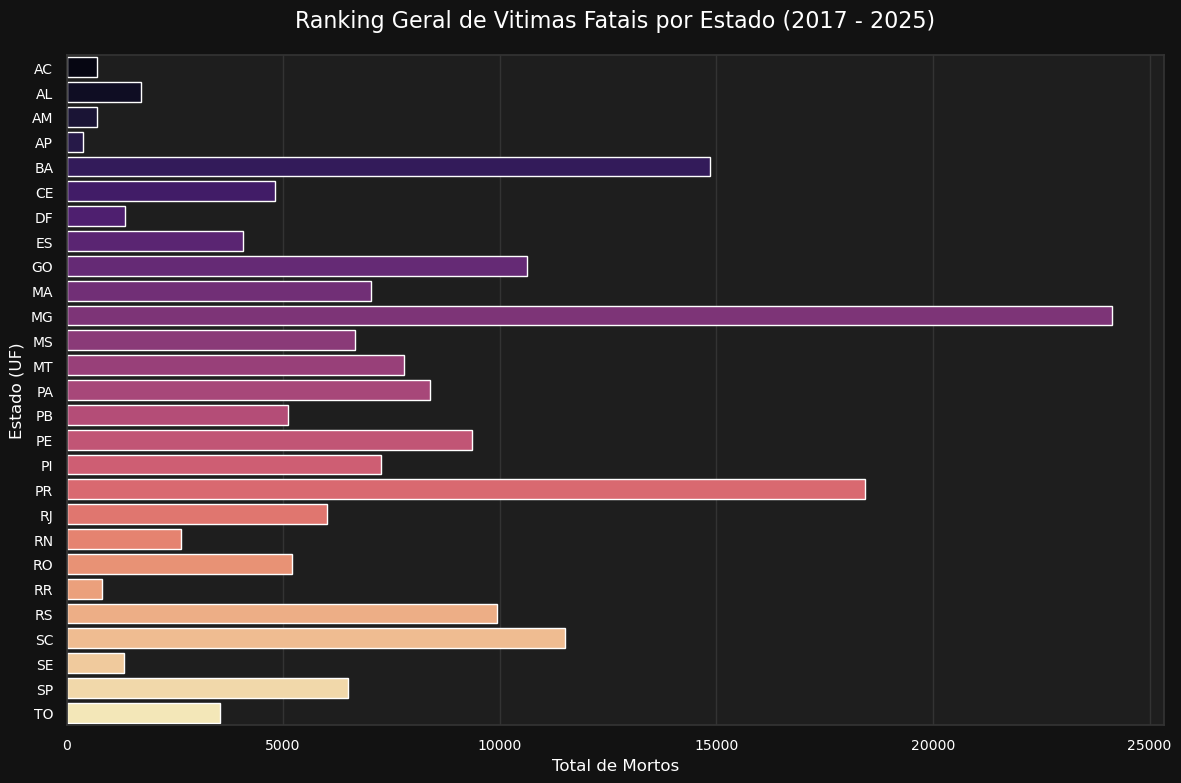

In [16]:
print("\nGerando graficos para o relatorio...")

apply_dark_theme()

# Grafico 1: resultado da consulta do maior corte temporal.
# Como a variavel consulta fica com o ultimo corte do loop anterior, ela representa o limite maximo do dataset.
ranking_completo = consulta.sort_values(by="mortos", ascending=False).reset_index()

plt.figure(figsize=(12, 8))
sns.barplot(
    data=ranking_completo,
    x="mortos",
    y="uf",
    hue="uf",
    palette="magma",
    dodge=False,
    legend=False,
)

plt.title("Ranking Geral de Vitimas Fatais por Estado (2017 - 2025)", fontsize=16, color="white", pad=20)
plt.xlabel("Total de Mortos", color="white", fontsize=12)
plt.ylabel("Estado (UF)", color="white", fontsize=12)
plt.tick_params(colors="white", which="both", labelsize=10)

save_report_figure(REPORTS_DIR, "grafico_consulta_estados.png")
plt.show()


**Explicacao do grafico:** Este grafico mostra o ranking geral de vitimas fatais por estado no periodo analisado. Ele ajuda a identificar quais UFs concentram os maiores totais de mortes no dataset.


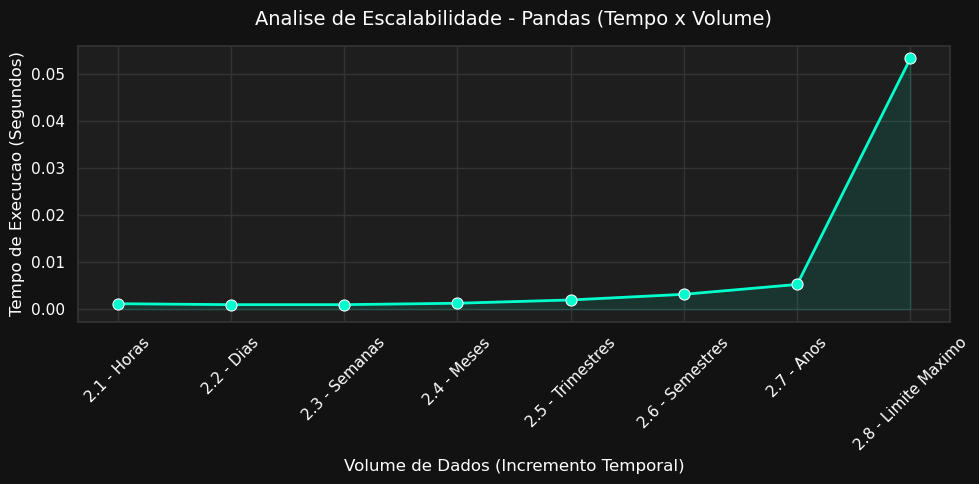

Graficos salvos com sucesso na pasta reports/.


In [17]:
# Grafico 2: escalabilidade do Pandas conforme o volume temporal aumenta.
plt.figure(figsize=(10, 5))

grafico_linha = sns.lineplot(
    data=df_resultados,
    x="Volume",
    y="Tempo_Segundos",
    marker="o",
    color="#00ffcc",
    linewidth=2,
    markersize=8,
)

plt.fill_between(
    df_resultados["Volume"],
    df_resultados["Tempo_Segundos"],
    color="#00ffcc",
    alpha=0.1,
)

plt.title("Analise de Escalabilidade - Pandas (Tempo x Volume)", fontsize=14, color="white", pad=15)
plt.xlabel("Volume de Dados (Incremento Temporal)", color="white")
plt.ylabel("Tempo de Execucao (Segundos)", color="white")
plt.xticks(rotation=45)

save_report_figure(REPORTS_DIR, "grafico_desempenho_pandas.png")
plt.show()

print("Graficos salvos com sucesso na pasta reports/.")


**Explicacao do grafico:** Este grafico mostra como o tempo de execucao do Pandas varia conforme o volume de dados aumenta. A ideia e observar se o crescimento do tempo acompanha o crescimento das linhas processadas.


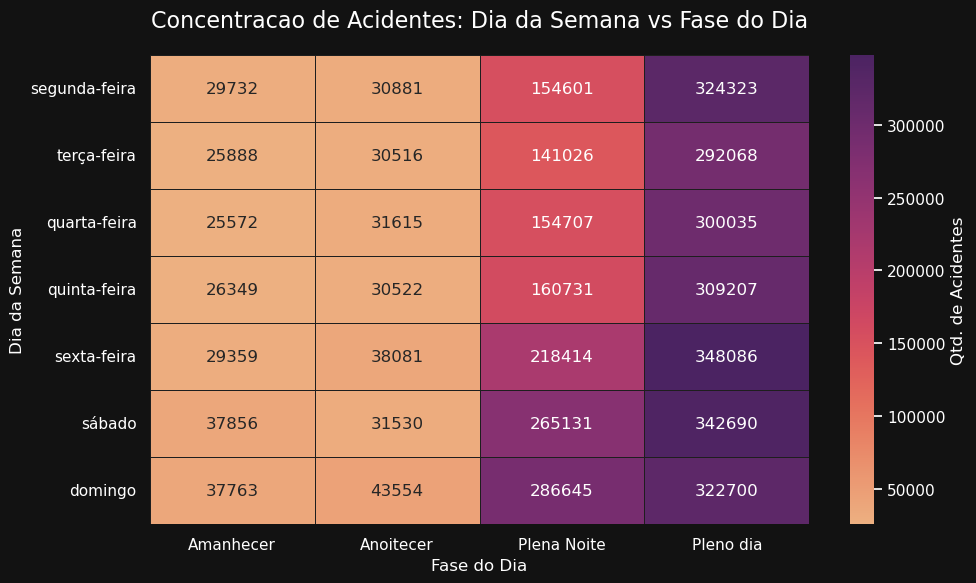

In [18]:
# Grafico 3: heatmap de concentracao por dia da semana e fase do dia.
matriz_dia_fase = df_completo.groupby(["dia_semana", "fase_dia"], observed=True).size().unstack(fill_value=0)

ordem_dias = ["segunda-feira", "terça-feira", "quarta-feira", "quinta-feira", "sexta-feira", "sábado", "domingo"]
ordem_dias = [dia for dia in ordem_dias if dia in matriz_dia_fase.index]
if ordem_dias:
    matriz_dia_fase = matriz_dia_fase.reindex(ordem_dias)

plt.figure(figsize=(10, 6))
sns.heatmap(
    matriz_dia_fase,
    cmap="flare",
    annot=True,
    fmt="d",
    cbar_kws={"label": "Qtd. de Acidentes"},
    linewidths=.5,
    linecolor="#1e1e1e",
)

plt.title("Concentracao de Acidentes: Dia da Semana vs Fase do Dia", fontsize=16, color="white", pad=20)
plt.xlabel("Fase do Dia", color="white", fontsize=12)
plt.ylabel("Dia da Semana", color="white", fontsize=12)
plt.tick_params(colors="white", which="both")

cbar = plt.gca().collections[0].colorbar
cbar.ax.yaxis.set_tick_params(color="white", labelcolor="white")
cbar.set_label("Qtd. de Acidentes", color="white")

save_report_figure(REPORTS_DIR, "grafico_consulta_heatmap.png")
plt.show()


**Explicacao do grafico:** O heatmap cruza dia da semana com fase do dia para mostrar onde ha maior concentracao de acidentes. Cores mais intensas indicam combinacoes com maior quantidade de registros.


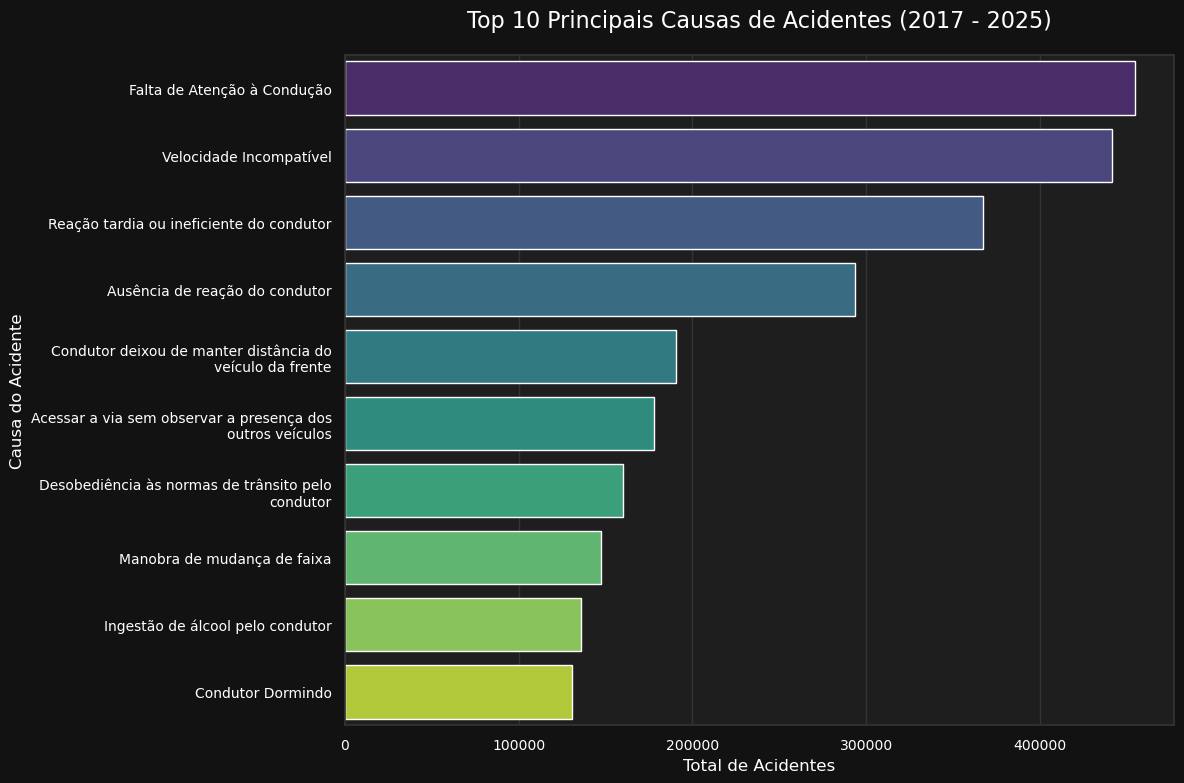

In [19]:
# Grafico 4: top 10 causas mais frequentes de acidentes.
# O dataset da PRF possui a coluna causa_principal para diferenciar a causa principal
# das causas associadas. Quando ela estiver disponivel, o ranking abaixo usa somente
# as causas principais e conta acidentes unicos pelo identificador id, evitando
# duplicidade por pessoa envolvida ou por repeticao da mesma causa.
df_causas = df_completo.copy()
if "causa_principal" in df_causas.columns:
    mascara_causa_principal = df_causas["causa_principal"].astype(str).str.strip().str.lower().eq("sim")
    df_causas = df_causas[mascara_causa_principal]

causas = (
    df_causas
    .dropna(subset=["causa_acidente"])
    .groupby("causa_acidente", observed=True)["id"]
    .nunique()
    .reset_index(name="total_acidentes")
)
top_10_causas = causas.sort_values(by="total_acidentes", ascending=False).head(10)

# Evita categorias vazias no Seaborn e quebra textos longos para melhorar a leitura do eixo Y.
top_10_causas["causa_acidente"] = top_10_causas["causa_acidente"].astype(str)
top_10_causas["causa_acidente"] = top_10_causas["causa_acidente"].apply(lambda x: textwrap.fill(x, width=45))

plt.figure(figsize=(12, 8))
sns.barplot(
    data=top_10_causas,
    x="total_acidentes",
    y="causa_acidente",
    palette="viridis",
    hue="causa_acidente",
    dodge=False,
    legend=False,
)

plt.title("Top 10 Causas Principais de Acidentes (2017 - 2025)", fontsize=16, color="white", pad=20)
plt.xlabel("Total de Acidentes Unicos", color="white", fontsize=12)
plt.ylabel("Causa do Acidente", color="white", fontsize=12)
plt.tick_params(colors="white", which="both", labelsize=10)

save_report_figure(REPORTS_DIR, "grafico_consulta_causas.png")
plt.show()


**Explicacao do grafico:** Este grafico apresenta as dez causas principais de acidente mais frequentes quando a coluna `causa_principal` esta disponivel. A contagem usa acidentes unicos (`id`) para evitar inflar o ranking por quantidade de pessoas envolvidas ou por repeticoes no arquivo de todas as causas e tipos.


## 3 - Comparacao de desempenho entre bibliotecas

O benchmark compara Pandas, Polars, PyArrow e Dask executando a mesma tarefa: leitura dos Parquets, filtro por intervalo de data e agregacao por UF.

A comparacao com Dask usa `LocalCluster`, ou seja, mede um ambiente local. Ela nao substitui o requisito de processamento distribuido em 1, 2 e 3 maquinas fisicas, que foi desconsiderado por limitacao externa.

A funcao `measure_seconds`, extraida para `src/utils/benchmark.py`, padroniza a medicao de tempo entre as bibliotecas.


In [21]:
# Benchmark local. O Dask entra apenas como comparacao de biblioteca, usando LocalCluster.
cluster = LocalCluster(n_workers=4, threads_per_worker=2)
client = Client(cluster)
print(f"Dask Dashboard disponivel em: {client.dashboard_link}\n")

cortes_tempo = {
    "2.1 - Horas": "2017-01-01 00:59:59",
    "2.2 - Dias": "2017-01-01 23:59:59",
    "2.3 - Semanas": "2017-01-07 23:59:59",
    "2.4 - Meses": "2017-01-31 23:59:59",
    "2.5 - Trimestres": "2017-03-31 23:59:59",
    "2.6 - Semestres": "2017-06-30 23:59:59",
    "2.7 - Anos": "2017-12-31 23:59:59",
    "2.8 - Limite Maximo": "2025-12-31 23:59:59",
}

data_inicial_str = "2017-01-01 00:00:00"
resultados_gerais = []

print("Iniciacao do Benchmark\n")

for nome_corte, data_final_str in cortes_tempo.items():
    print(f"Testando volume: {nome_corte}")

    data_inicial_dt = datetime.strptime(data_inicial_str, "%Y-%m-%d %H:%M:%S")
    data_final_dt = datetime.strptime(data_final_str, "%Y-%m-%d %H:%M:%S")

    # Metodo 1: Pandas.
    def run_pandas():
        df_pd = pd.read_parquet(PARQUET_DIR)
        df_pd["data_inversa"] = pd.to_datetime(df_pd["data_inversa"])
        if "data_hora" not in df_pd.columns:
            df_pd["data_hora"] = pd.to_datetime(
                df_pd["data_inversa"].dt.strftime("%Y-%m-%d") + " " + df_pd["horario"].astype(str),
                errors="coerce",
            )
        df_pd["data_hora"] = pd.to_datetime(df_pd["data_hora"], errors="coerce")
        mask = (df_pd["data_hora"] >= data_inicial_dt) & (df_pd["data_hora"] <= data_final_dt)
        return df_pd[mask].groupby("uf", observed=True)[["mortos", "feridos_graves"]].sum()

    pandas_res, t_pandas = measure_seconds(run_pandas)

    # Metodo 2: Polars com lazy evaluation.
    def run_polars():
        df_pl = pl.scan_parquet(str(PARQUET_DIR / "*.parquet"))
        query_polars = (
            df_pl
            .filter((pl.col("data_hora") >= data_inicial_dt) & (pl.col("data_hora") <= data_final_dt))
            .group_by("uf")
            .agg([pl.col("mortos").sum(), pl.col("feridos_graves").sum()])
        )
        return query_polars.collect()

    polars_res, t_polars = measure_seconds(run_polars)

    # Metodo 3: PyArrow Dataset.
    def run_pyarrow():
        dataset_arrow = ds.dataset(PARQUET_DIR, format="parquet")
        filtro = (pc.field("data_hora") >= data_inicial_dt) & (pc.field("data_hora") <= data_final_dt)
        tabela_filtrada = dataset_arrow.to_table(filter=filtro)
        return tabela_filtrada.group_by("uf").aggregate([("mortos", "sum"), ("feridos_graves", "sum")])

    arrow_res, t_arrow = measure_seconds(run_pyarrow)

    # Metodo 4: Dask local.
    def run_dask():
        df_dd = dd.read_parquet(str(PARQUET_DIR / "*.parquet"))
        if "data_hora" not in df_dd.columns:
            df_dd["data_hora"] = dd.to_datetime(
                df_dd["data_inversa"].astype(str) + " " + df_dd["horario"].astype(str),
                errors="coerce",
            )
        mask_dd = (df_dd["data_hora"] >= data_inicial_str) & (df_dd["data_hora"] <= data_final_str)
        return df_dd[mask_dd].groupby("uf", observed=True)[["mortos", "feridos_graves"]].sum().compute()

    dask_res, t_dask = measure_seconds(run_dask)

    resultados_gerais.append({"Volume": nome_corte, "Biblioteca": "Pandas", "Tempo (s)": t_pandas})
    resultados_gerais.append({"Volume": nome_corte, "Biblioteca": "Polars", "Tempo (s)": t_polars})
    resultados_gerais.append({"Volume": nome_corte, "Biblioteca": "PyArrow", "Tempo (s)": t_arrow})
    resultados_gerais.append({"Volume": nome_corte, "Biblioteca": "Dask", "Tempo (s)": t_dask})

    print(f" -> Pandas: {t_pandas:.4f}s | Polars: {t_polars:.4f}s | PyArrow: {t_arrow:.4f}s | Dask: {t_dask:.4f}s\n")

# Fecha explicitamente o cluster local para liberar recursos ao final do benchmark.
client.close()
cluster.close()


Dask Dashboard disponivel em: http://127.0.0.1:8787/status

Iniciacao do Benchmark

Testando volume: 2.1 - Horas
 -> Pandas: 0.4833s | Polars: 0.0092s | PyArrow: 0.0122s | Dask: 0.5849s

Testando volume: 2.2 - Dias
 -> Pandas: 0.4906s | Polars: 0.0099s | PyArrow: 0.0120s | Dask: 0.2086s

Testando volume: 2.3 - Semanas
 -> Pandas: 0.4768s | Polars: 0.0100s | PyArrow: 0.0111s | Dask: 0.1563s

Testando volume: 2.4 - Meses
 -> Pandas: 0.4616s | Polars: 0.0109s | PyArrow: 0.0124s | Dask: 0.1565s

Testando volume: 2.5 - Trimestres
 -> Pandas: 0.4724s | Polars: 0.0102s | PyArrow: 0.0130s | Dask: 0.1569s

Testando volume: 2.6 - Semestres
 -> Pandas: 0.4736s | Polars: 0.0099s | PyArrow: 0.0132s | Dask: 0.1569s

Testando volume: 2.7 - Anos
 -> Pandas: 0.4852s | Polars: 0.0101s | PyArrow: 0.0146s | Dask: 0.1608s

Testando volume: 2.8 - Limite Maximo
 -> Pandas: 0.6000s | Polars: 0.0287s | PyArrow: 0.0939s | Dask: 0.1833s



In [ ]:
# Resumo textual do benchmark entre bibliotecas.
df_resultados_benchmark = pd.DataFrame(resultados_gerais)
df_resumo_benchmark = (
    df_resultados_benchmark
    .groupby("Biblioteca")["Tempo (s)"]
    .agg(tempo_medio_s="mean", menor_tempo_s="min", maior_tempo_s="max")
    .reset_index()
    .sort_values("tempo_medio_s")
)
vencedores_por_volume = (
    df_resultados_benchmark
    .sort_values("Tempo (s)")
    .groupby("Volume", as_index=False)
    .first()[["Volume", "Biblioteca", "Tempo (s)"]]
)

df_resumo_benchmark.to_csv(REPORTS_DIR / "resumo_benchmark_bibliotecas.csv", index=False)
vencedores_por_volume.to_csv(REPORTS_DIR / "vencedores_benchmark_por_volume.csv", index=False)

display(df_resumo_benchmark)
display(vencedores_por_volume)

biblioteca_mais_rapida = df_resumo_benchmark.iloc[0]["Biblioteca"]
tempo_medio_mais_rapido = df_resumo_benchmark.iloc[0]["tempo_medio_s"]
print(
    f"No benchmark executado, {biblioteca_mais_rapida} teve o menor tempo medio "
    f"({tempo_medio_mais_rapido:.4f}s) para a consulta de filtro por data "
    "e agrupamento por UF."
)


## Grafico comparativo das bibliotecas

O grafico final resume os tempos medidos para cada biblioteca nos diferentes volumes temporais. Ele ajuda a visualizar overhead inicial, escalabilidade e diferencas de abordagem entre execucao ansiosa, lazy evaluation, processamento colunar e agendamento local do Dask.


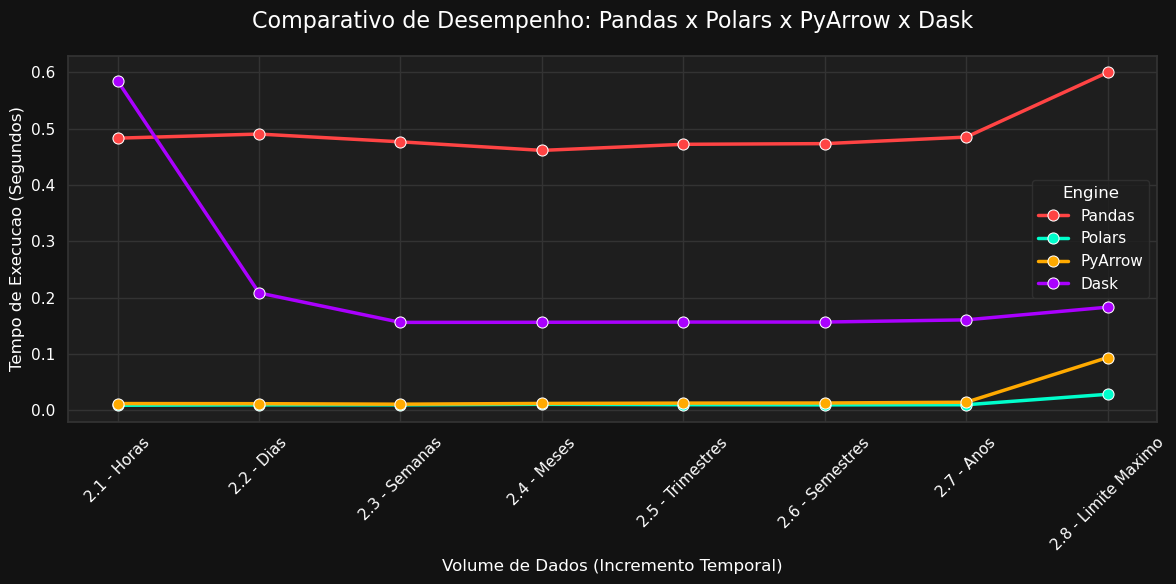

Grafico final salvo em reports/.


In [22]:
df_resultados_benchmark = pd.DataFrame(resultados_gerais)

apply_dark_theme()

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df_resultados_benchmark,
    x="Volume",
    y="Tempo (s)",
    hue="Biblioteca",
    marker="o",
    linewidth=2.5,
    markersize=8,
    palette=["#ff4444", "#00ffcc", "#ffaa00", "#aa00ff"],
)

plt.title("Comparativo de Desempenho: Pandas x Polars x PyArrow x Dask", fontsize=16, color="white", pad=20)
plt.xlabel("Volume de Dados (Incremento Temporal)", color="white", fontsize=12)
plt.ylabel("Tempo de Execucao (Segundos)", color="white", fontsize=12)
plt.xticks(rotation=45)
plt.tick_params(colors="white", which="both")

legenda = plt.legend(title="Engine", facecolor="#1e1e1e", edgecolor="#333333")
for text in legenda.get_texts():
    text.set_color("white")
legenda.get_title().set_color("white")

save_report_figure(REPORTS_DIR, "grafico_benchmark_completo.png")
plt.show()

print("Grafico final salvo em reports/.")


**Explicacao do grafico:** Este grafico compara os tempos de execucao das bibliotecas Pandas, Polars, PyArrow e Dask local. Ele resume o comportamento de desempenho de cada ferramenta nos diferentes volumes de dados.


## Insights de desempenho

Os pontos abaixo interpretam os resultados obtidos no benchmark. Eles foram mantidos como apoio para a apresentacao e para a defesa tecnica do trabalho.


- O Polars foi a biblioteca mais rápida em todos os cortes do benchmark registrado. Na consulta de filtro por `data_hora` e agrupamento por `uf`, ele variou de aproximadamente 0,0092s nos menores volumes a 0,0287s no limite máximo do dataset.

- O PyArrow também teve desempenho muito bom por trabalhar diretamente sobre dados colunares: ficou próximo do Polars nos volumes menores, mas no limite máximo subiu para aproximadamente 0,0939s.

- O Dask apresentou maior overhead no primeiro corte por horas (aproximadamente 0,5849s), comportamento esperado por causa da inicialização do agendador e do grafo de tarefas. Depois do primeiro corte, manteve tempos mais estáveis, entre cerca de 0,1563s e 0,2086s, terminando em 0,1833s no limite máximo.

- O Pandas foi a opção mais lenta neste benchmark de leitura + filtro + agrupamento, variando de aproximadamente 0,4616s a 0,6000s. A principal explicação é que ele carrega o conjunto Parquet para a memória de forma ansiosa antes de aplicar a consulta, enquanto Polars e PyArrow conseguem se beneficiar mais do formato colunar.


## Referencias e fontes

- Dataset: arquivos CSV de acidentes utilizados na pasta `data/raw/`.
- Requisitos do trabalho: PDF salvo em `reports/requisitos_trabalho.pdf`.
- Pandas: https://pandas.pydata.org/docs/
- PyArrow: https://arrow.apache.org/docs/python/
- Polars: https://docs.pola.rs/
- Dask: https://docs.dask.org/


## Observacao sobre processamento paralelo distribuido

A comparacao com Dask foi mantida no benchmark local usando `LocalCluster`. O processamento paralelo distribuido em 1, 2 e 3 maquinas fisicas nao foi executado, portanto esse item foi documentado como nao aplicavel nesta entrega.
